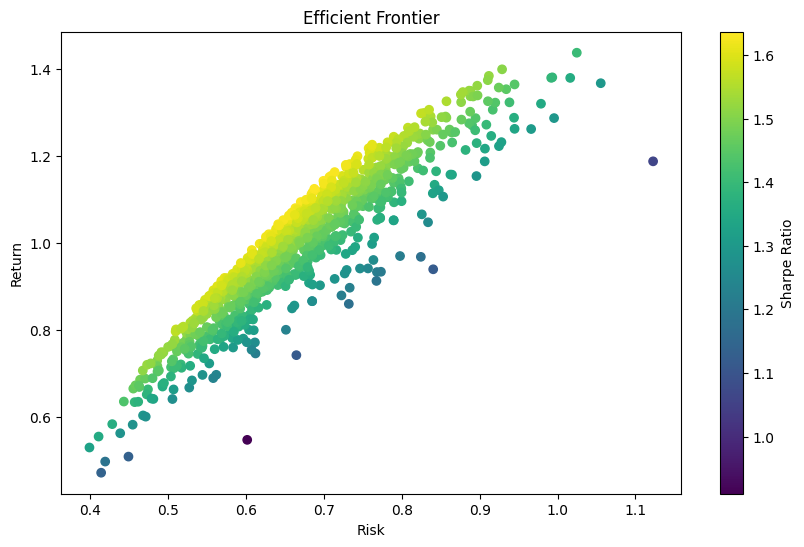

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

selected = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:5]
    )
]

pivot = selected.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change().dropna()

mean_returns = returns.mean()

cov_matrix = returns.cov()

num_portfolios = 1000

results = []

for i in range(num_portfolios):

    weights = np.random.random(5)

    weights /= np.sum(weights)

    portfolio_return = np.sum(
        mean_returns * weights
    ) * 252

    portfolio_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix * 252,
                weights
            )
        )
    )

    sharpe = portfolio_return / portfolio_risk

    results.append([
        portfolio_risk,
        portfolio_return,
        sharpe
    ])

results = np.array(results)

plt.figure(figsize=(10,6))

plt.scatter(
    results[:,0],
    results[:,1],
    c=results[:,2]
)

plt.xlabel("Risk")

plt.ylabel("Return")

plt.title(
    "Efficient Frontier"
)

plt.colorbar(label="Sharpe Ratio")

plt.show()

In [2]:
plt.savefig(
    "../reports/charts/efficient_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>